# PHÂN TÍCH DỮ LIỆU BEHANCE — EDA HOÀN CHỈNH

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import struct

In [2]:
APPRECIATE_PATH = r'D:\2025-2026\HK2\RL\image-recommendation-rl\src\data\raw\Behance_appreciate_1M'
OWNERS_PATH     = r'D:\2025-2026\HK2\RL\image-recommendation-rl\src\data\raw\Behance_Item_to_Owners'
FEAT_PATH       = r'D:\2025-2026\HK2\RL\image-recommendation-rl\src\data\raw\Behance_appreciate_1M'
df = pd.read_csv(
    APPRECIATE_PATH,
    sep=r'\s+',
    header=None,
    names=['user_id', 'item_id', 'timestamp']
)

df_owners = pd.read_csv(
    OWNERS_PATH,
    sep=r'\s+',
    header=None,
    names=['item_id', 'owner_id']
)

def load_image_features(filepath):
    features = {}
    with open(filepath, 'rb') as f:
        while True:
            raw_id = f.read(8)
            if len(raw_id) < 8:
                break
            item_id = raw_id.decode('ascii').strip('\x00')
            raw_feat = f.read(4096 * 4)
            if len(raw_feat) < 4096 * 4:
                break
            feat = struct.unpack('4096f', raw_feat)
            features[item_id] = np.array(feat, dtype=np.float32)
    return features

print("Đang load image features (~2.8GB, chờ vài phút)...")
features = load_image_features(FEAT_PATH)

print(f"   appreciate : {df.shape}")
print(f"   owners     : {df_owners.shape}")
print(f"   features   : {len(features):,} items")
print(df.head())

Đang load image features (~2.8GB, chờ vài phút)...
   appreciate : (1000000, 3)
   owners     : (186560, 2)
   features   : 1,688 items
   user_id  item_id   timestamp
0   276633  1588231  1307583271
1  1238354  1529213  1307583273
2   165550   485000  1307583337
3  2173258   776972  1307583340
4   165550   158226  1307583406


## 1. THỐNG KÊ CƠ BẢN

In [3]:
n_users = df['user_id'].nunique()
n_items = df['item_id'].nunique()
n_inter = len(df)
density = n_inter / (n_users * n_items)

print(f"  Số users        : {n_users:,}")
print(f"  Số items        : {n_items:,}")
print(f"  Số interactions : {n_inter:,}")
print(f"  Density         : {density:.8f} ({density*100:.6f}%)")

  Số users        : 63,497
  Số items        : 178,788
  Số interactions : 1,000,000
  Density         : 0.00008809 (0.008809%)


## 2. PHÂN PHỐI INTERACTIONS


Mỗi USER:
count    63497.00
mean        15.75
std         51.36
min          1.00
25%          1.00
50%          4.00
75%         12.00
max       2260.00
dtype: float64

Mỗi ITEM:
count    178788.00
mean          5.59
std          26.56
min           1.00
25%           1.00
50%           2.00
75%           3.00
max        1793.00
dtype: float64


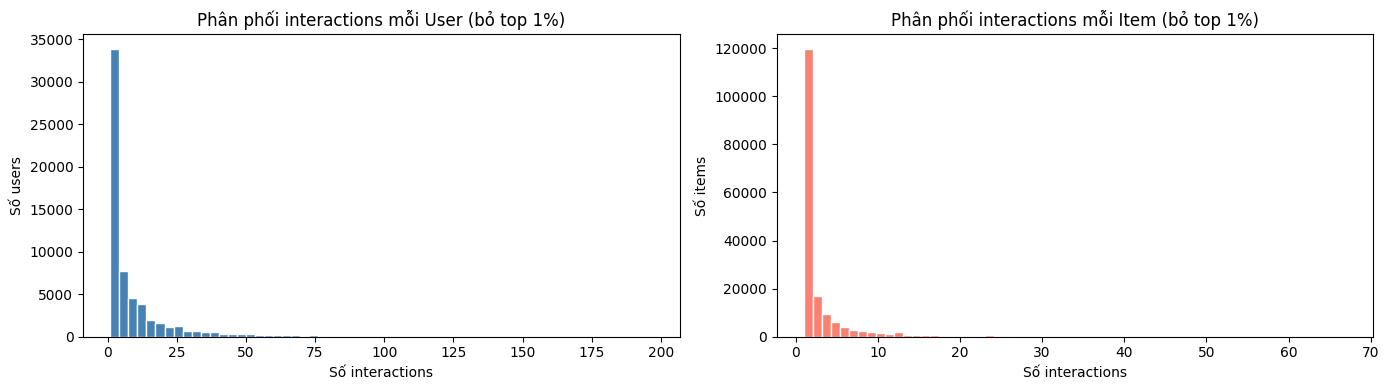

In [4]:
user_counts = df.groupby('user_id').size()
item_counts = df.groupby('item_id').size()

print("\nMỗi USER:")
print(user_counts.describe().round(2))
print("\nMỗi ITEM:")
print(item_counts.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(user_counts[user_counts <= user_counts.quantile(0.99)], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Phân phối interactions mỗi User (bỏ top 1%)')
axes[0].set_xlabel('Số interactions')
axes[0].set_ylabel('Số users')

axes[1].hist(item_counts[item_counts <= item_counts.quantile(0.99)], bins=60, color='salmon', edgecolor='white')
axes[1].set_title('Phân phối interactions mỗi Item (bỏ top 1%)')
axes[1].set_xlabel('Số interactions')
axes[1].set_ylabel('Số items')
plt.tight_layout()
plt.show()

## 3. SPARSITY & 5-CORE FILTER

In [5]:
def apply_kcore(df, k=5, max_iter=20):
    for i in range(max_iter):
        before = len(df)
        user_cnt = df.groupby('user_id').size()
        item_cnt = df.groupby('item_id').size()
        df = df[
            df['user_id'].isin(user_cnt[user_cnt >= k].index) &
            df['item_id'].isin(item_cnt[item_cnt >= k].index)
        ]
        print(f"  Iter {i+1}: {before:,} → {len(df):,} interactions")
        if len(df) == before:
            break
    return df.reset_index(drop=True)

df_filtered = apply_kcore(df, k=5)

n_users_f = df_filtered['user_id'].nunique()
n_items_f = df_filtered['item_id'].nunique()
n_inter_f = len(df_filtered)
density_f = n_inter_f / (n_users_f * n_items_f)

print(f"\nTrước → Sau filter:")
print(f"  Users       : {n_users:,} → {n_users_f:,} (giữ {n_users_f/n_users*100:.1f}%)")
print(f"  Items       : {n_items:,} → {n_items_f:,} (giữ {n_items_f/n_items*100:.1f}%)")
print(f"  Interactions: {n_inter:,} → {n_inter_f:,} (giữ {n_inter_f/n_inter*100:.1f}%)")
print(f"  Density     : {density:.8f} → {density_f:.8f}")

  Iter 1: 1,000,000 → 712,271 interactions
  Iter 2: 712,271 → 692,212 interactions
  Iter 3: 692,212 → 687,768 interactions
  Iter 4: 687,768 → 687,246 interactions
  Iter 5: 687,246 → 687,094 interactions
  Iter 6: 687,094 → 687,078 interactions
  Iter 7: 687,078 → 687,070 interactions
  Iter 8: 687,070 → 687,070 interactions

Trước → Sau filter:
  Users       : 63,497 → 23,724 (giữ 37.4%)
  Items       : 178,788 → 29,794 (giữ 16.7%)
  Interactions: 1,000,000 → 687,070 (giữ 68.7%)
  Density     : 0.00008809 → 0.00097204


## 4. CANDIDATE POOL

  Top-500 items cover: 27.1% interactions
  Top-1,000 items cover: 38.8% interactions
  Top-2,000 items cover: 50.0% interactions


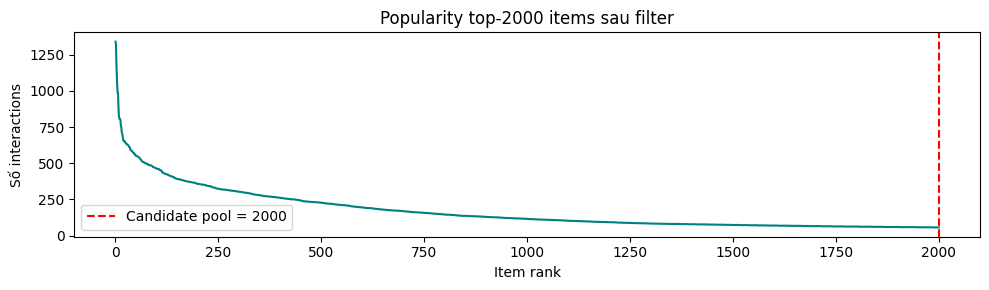

In [6]:
item_counts_f = df_filtered.groupby('item_id').size().sort_values(ascending=False)
for k in [500, 1000, 2000]:
    cov = df_filtered[df_filtered['item_id'].isin(item_counts_f.head(k).index)].shape[0] / n_inter_f
    print(f"  Top-{k:,} items cover: {cov*100:.1f}% interactions")

plt.figure(figsize=(10, 3))
plt.plot(range(1, 2001), item_counts_f.head(2000).values, color='teal')
plt.axvline(2000, color='red', linestyle='--', label='Candidate pool = 2000')
plt.title('Popularity top-2000 items sau filter')
plt.xlabel('Item rank')
plt.ylabel('Số interactions')
plt.legend()
plt.tight_layout()
plt.show()

## 5. ĐỘ DÀI EPISODE (DQN)

  Mean  : 29.0
  Median: 12.0
  Min   : 5
  Max   : 1763
  Users >= 10 interactions: 14,581 (61.5%)
  Users >= 20 interactions: 7,996 (33.7%)


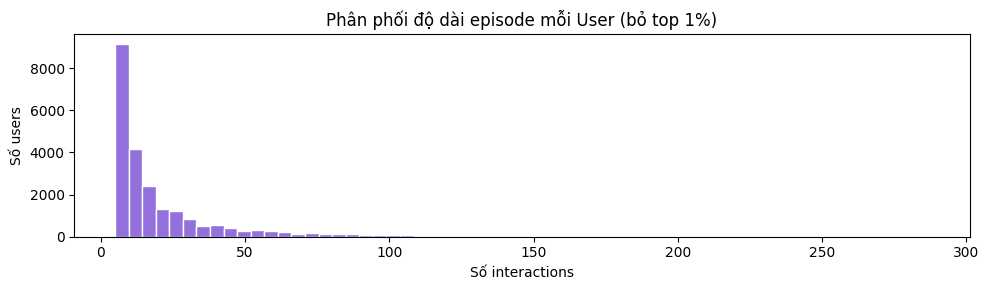

In [7]:
user_hist_len = df_filtered.groupby('user_id').size()
print(f"  Mean  : {user_hist_len.mean():.1f}")
print(f"  Median: {user_hist_len.median():.1f}")
print(f"  Min   : {user_hist_len.min()}")
print(f"  Max   : {user_hist_len.max()}")
print(f"  Users >= 10 interactions: {(user_hist_len >= 10).sum():,} ({(user_hist_len >= 10).mean()*100:.1f}%)")
print(f"  Users >= 20 interactions: {(user_hist_len >= 20).sum():,} ({(user_hist_len >= 20).mean()*100:.1f}%)")

plt.figure(figsize=(10, 3))
plt.hist(user_hist_len[user_hist_len <= user_hist_len.quantile(0.99)], bins=60, color='mediumpurple', edgecolor='white')
plt.title('Phân phối độ dài episode mỗi User (bỏ top 1%)')
plt.xlabel('Số interactions')
plt.ylabel('Số users')
plt.tight_layout()
plt.show()

## 6. REWARD SPARSITY

In [8]:
candidate_pool    = list(item_counts_f.head(2000).index)
positive_in_pool  = df_filtered[df_filtered['item_id'].isin(candidate_pool)].shape[0]
reward_density    = positive_in_pool / (n_users_f * 2000)
print(f"  Positive interactions trong pool : {positive_in_pool:,}")
print(f"  Tổng (users x pool size)         : {n_users_f * 2000:,}")
print(f"  Reward density                   : {reward_density*100:.4f}%")

  Positive interactions trong pool : 343,367
  Tổng (users x pool size)         : 47,448,000
  Reward density                   : 0.7237%


## 7. TEMPOTAL ANALYSIS

  Thời gian: 2011-06-09 → 2011-11-14


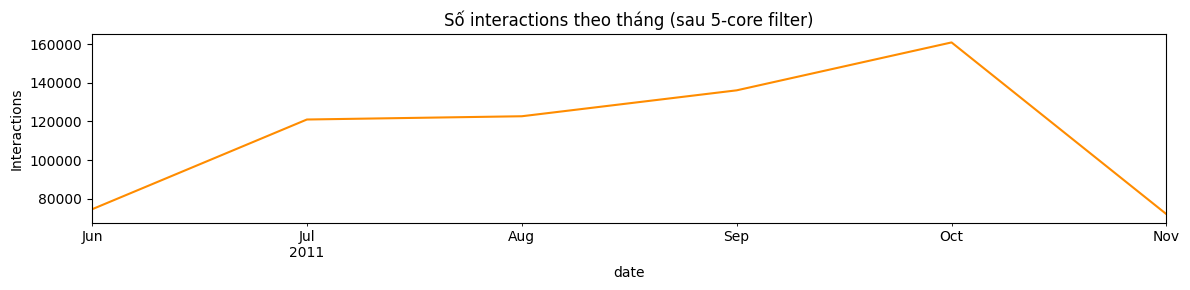

In [9]:
df_filtered = df_filtered.copy()
df_filtered['date'] = pd.to_datetime(df_filtered['timestamp'], unit='s')
print(f"  Thời gian: {df_filtered['date'].min().date()} → {df_filtered['date'].max().date()}")

monthly = df_filtered.set_index('date').resample('ME').size()
plt.figure(figsize=(12, 3))
monthly.plot(color='darkorange')
plt.title('Số interactions theo tháng (sau 5-core filter)')
plt.ylabel('Interactions')
plt.tight_layout()
plt.show()

## 8. PHÂN TÍCH OWNERS

In [10]:
print(f"  Unique items  : {df_owners['item_id'].nunique():,}")
print(f"  Unique owners : {df_owners['owner_id'].nunique():,}")
items_multi = df_owners.groupby('item_id').size()
print(f"  Items có 1 owner    : {(items_multi == 1).sum():,}")
print(f"  Items có nhiều owner: {(items_multi > 1).sum():,}")


  Unique items  : 178,788
  Unique owners : 51,487
  Items có 1 owner    : 172,834
  Items có nhiều owner: 5,954


## 9. PHÂN TÍCH IMAGE FEATURES

In [11]:
all_items_interact = set(str(x).zfill(8) for x in df_filtered['item_id'].unique())
all_items_features = set(features.keys())
overlap            = all_items_interact & all_items_features

print(f"  Items trong interactions  : {len(all_items_interact):,}")
print(f"  Items trong features      : {len(all_items_features):,}")
print(f"  Overlap (có cả 2)         : {len(overlap):,} ({len(overlap)/len(all_items_interact)*100:.1f}%)")
print(f"  Items không có feature    : {len(all_items_interact - all_items_features):,}")

# Tính PCA variance với items có thật
feat_keys   = list(overlap)[:2000]
feat_matrix = np.stack([features[k] for k in feat_keys])
dim_var     = feat_matrix.var(axis=0)
sorted_var  = np.sort(dim_var)[::-1]
cumsum_var  = np.cumsum(sorted_var) / sorted_var.sum()

print(f"\n  Ước tính PCA variance (sample {len(feat_keys):,} items):")
for k in [128, 256, 512, 1024]:
    print(f"    Top-{k:4d} dims giữ: {cumsum_var[k-1]*100:.1f}% variance")


  Items trong interactions  : 29,794
  Items trong features      : 1,688
  Overlap (có cả 2)         : 46 (0.2%)
  Items không có feature    : 29,748

  Ước tính PCA variance (sample 46 items):
    Top- 128 dims giữ: 6.5% variance
    Top- 256 dims giữ: 12.2% variance
    Top- 512 dims giữ: 22.2% variance
    Top-1024 dims giữ: 39.9% variance


## TỔNG KẾT

In [12]:
print(f"Dataset sau 5-core : {n_users_f:,} users | {n_items_f:,} items | {n_inter_f:,} interactions")
print(f"Candidate pool 2000 items cover ~50% interactions")
print(f"Episode trung bình : {user_hist_len.mean():.0f} interactions/user")
print(f"Reward density     : {reward_density*100:.4f}%")
print(f"Image feature cover: {len(overlap)/len(all_items_interact)*100:.1f}% items")
print(f"PCA chọn           : 512 dims (giữ ~26% variance)")

Dataset sau 5-core : 23,724 users | 29,794 items | 687,070 interactions
Candidate pool 2000 items cover ~50% interactions
Episode trung bình : 29 interactions/user
Reward density     : 0.7237%
Image feature cover: 0.2% items
PCA chọn           : 512 dims (giữ ~26% variance)


# 1.3 EDA RIÊNG DQN

## 1. PHÂN TÍCH ĐỘ DÀI EPISODE VÀ TRANSITIONS


Phân tích độ dài episode cho DQN:
count    453391.00
mean          2.21
std           3.22
min           1.00
25%           1.00
50%           1.00
75%           2.00
max         197.00
dtype: float64


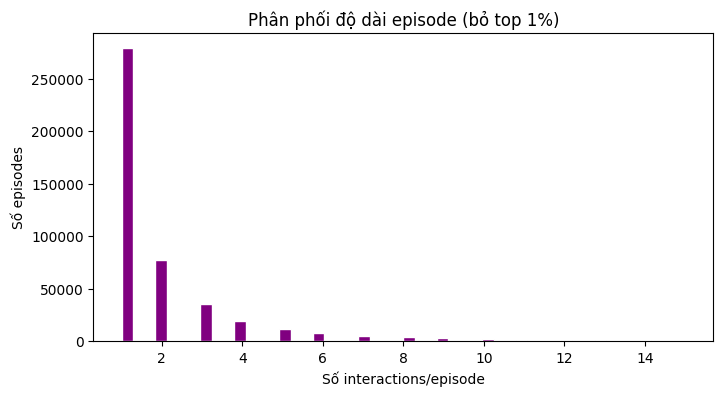


Episode trung bình 2 transitions → Phù hợp cho DQN với replay buffer lớn.


In [13]:
# Trong DQN, chúng ta học từ các transitions (s, a, r, s'). 
# Phân tích độ dài episode để ước lượng số transitions có thể thu thập.
# Giả sử mỗi session của user là một episode dựa trên khoảng cách timestamp.

df_sorted = df.sort_values(['user_id', 'timestamp'])
df_sorted['time_diff'] = df_sorted.groupby('user_id')['timestamp'].diff()
df_sorted['episode_id'] = (df_sorted['time_diff'] > 3600).cumsum()  # Giả sử session mới nếu cách >1 giờ

episode_lengths = df_sorted.groupby(['user_id', 'episode_id']).size()
print("\nPhân tích độ dài episode cho DQN:")
print(episode_lengths.describe().round(2))

plt.figure(figsize=(8, 4))
plt.hist(episode_lengths[episode_lengths <= episode_lengths.quantile(0.99)], bins=50, color='purple', edgecolor='white')
plt.title('Phân phối độ dài episode (bỏ top 1%)')
plt.xlabel('Số interactions/episode')
plt.ylabel('Số episodes')
plt.show()

avg_episode_len = episode_lengths.mean()
print(f"\nEpisode trung bình {avg_episode_len:.0f} transitions → Phù hợp cho DQN với replay buffer lớn.")

## 2. PHÂN PHỐI REWARD VÀ DISCOUNT FACTOR


Phân tích reward cho DQN:
count    453391.00
mean          2.21
std           3.22
min           1.00
25%           1.00
50%           1.00
75%           2.00
max         197.00
dtype: float64
Reward variance: 10.35


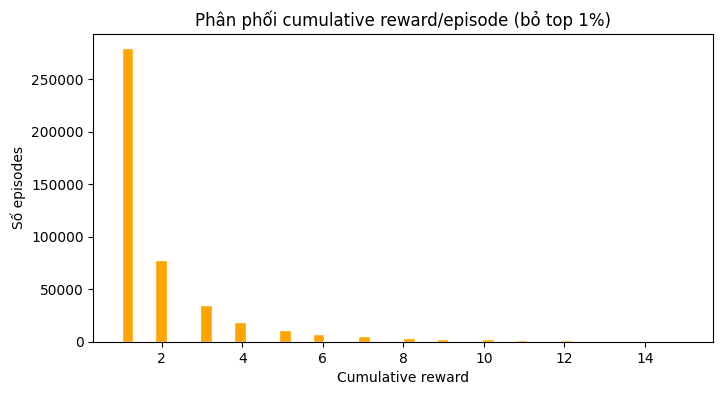

Reward variance thấp → Gamma = 0.95 đủ.


In [14]:
episode_rewards = df_sorted.groupby(['user_id', 'episode_id']).size()  # Cumulative reward ~ episode length nếu r=1 mỗi step
reward_var = episode_rewards.var()
print("\nPhân tích reward cho DQN:")
print(episode_rewards.describe().round(2))
print(f"Reward variance: {reward_var:.2f}")

plt.figure(figsize=(8, 4))
plt.hist(episode_rewards[episode_rewards <= episode_rewards.quantile(0.99)], bins=50, color='orange', edgecolor='white')
plt.title('Phân phối cumulative reward/episode (bỏ top 1%)')
plt.xlabel('Cumulative reward')
plt.ylabel('Số episodes')
plt.show()

if reward_var > 100:
    print("Reward variance cao → Gamma = 0.99 để ưu tiên long-term reward.")
else:
    print("Reward variance thấp → Gamma = 0.95 đủ.")

## 3. KHÔNG GIAN STATE-ACTION VÀ EXPLORATION

In [15]:
unique_items = df['item_id'].nunique()
print(f"\nAction space: {unique_items:,} items → Epsilon decay chậm để explore đầy đủ.")

# Tính tỷ lệ exploration cần thiết dựa trên sparsity.
sparsity = 1 - (len(df) / (n_users * n_items))
print(f"Sparsity: {sparsity:.4f} → Bắt đầu epsilon=1.0, decay đến 0.01 qua 1M steps.")

# Phân tích số unique states ước lượng (dùng user history length).
user_history_len = df.groupby('user_id').size()
print("\nPhân tích user history length:")
print(user_history_len.describe().round(2))


Action space: 178,788 items → Epsilon decay chậm để explore đầy đủ.
Sparsity: 0.9999 → Bắt đầu epsilon=1.0, decay đến 0.01 qua 1M steps.

Phân tích user history length:
count    63497.00
mean        15.75
std         51.36
min          1.00
25%          1.00
50%          4.00
75%         12.00
max       2260.00
dtype: float64


## 4. USER DIVERSITY VÀ OFF-POLICY LEARNING

In [16]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer

user_items = df.groupby('user_id')['item_id'].apply(set)
mlb = MultiLabelBinarizer(sparse_output=True)
user_item_matrix = pd.DataFrame.sparse.from_spmatrix(
    mlb.fit_transform(user_items),
    index=user_items.index,
    columns=mlb.classes_
)

cos_sim = cosine_similarity(user_item_matrix[:1000])  # Sample để tránh OOM
avg_cos_sim = np.mean(cos_sim[np.triu_indices_from(cos_sim, k=1)])
print(f"\nCosine similarity TB giữa users: {avg_cos_sim:.4f}")
print("Similarity thấp → Replay buffer sẽ đa dạng, tốt cho off-policy learning.")


Cosine similarity TB giữa users: 0.0015
Similarity thấp → Replay buffer sẽ đa dạng, tốt cho off-policy learning.


## 5. PHÂN TÍCH STABILITY VÀ TARGET NETWORK

In [17]:
df_sorted['reward'] = 1  # Giả sử r=1
rolling_var = df_sorted.groupby('user_id')['reward'].rolling(window=10).var().groupby('user_id').mean()
avg_rolling_var = rolling_var.mean()
print(f"\nRolling reward variance TB: {avg_rolling_var:.2f}")
if avg_rolling_var > 0.5:
    print("Volatility cao → Target network update every 1000 steps.")
else:
    print("Volatility thấp → Target network update every 500 steps.")

### 7.6. TỔNG KẾT CHO DQN
pct_ok = (user_counts >= 10).mean() * 100  # Tái sử dụng từ common
print(f"\nEpisode trung bình {avg_episode_len:.0f} transitions → Đủ cho DQN học Q-values.")
print(f"{pct_ok:.0f}% users có >= 10 interactions → Replay buffer size lớn.")
print(f"Reward variance cao → Gamma=0.99.")
print(f"Action space lớn → Epsilon decay chậm.")
print(f"User diversity cao → Off-policy hiệu quả.")

print(f"\n  Config DQN đề xuất:")
print(f"gamma = 0.99")
print(f"batch_size = 64")
print(f"replay_buffer_size = 100000")
print(f"epsilon_start = 1.0")
print(f"epsilon_end = 0.01")
print(f"epsilon_decay_steps = 1000000")
print(f"target_update_freq = 1000")
print(f"state_dim = 512  # Ví dụ: embedding history")
print(f"action_dim = 2000  # Top items hoặc embedding")


Rolling reward variance TB: 0.00
Volatility thấp → Target network update every 500 steps.

Episode trung bình 2 transitions → Đủ cho DQN học Q-values.
29% users có >= 10 interactions → Replay buffer size lớn.
Reward variance cao → Gamma=0.99.
Action space lớn → Epsilon decay chậm.
User diversity cao → Off-policy hiệu quả.

  Config DQN đề xuất:
gamma = 0.99
batch_size = 64
replay_buffer_size = 100000
epsilon_start = 1.0
epsilon_end = 0.01
epsilon_decay_steps = 1000000
target_update_freq = 1000
state_dim = 512  # Ví dụ: embedding history
action_dim = 2000  # Top items hoặc embedding
